# Gradient Descent and it's different variants

In this coding question, you'll implement a classifier with logistic regression
$$ F(w) = \frac{1}{N} \sum_{i=1}^N \log( 1 + e^{-\langle w, x_i \rangle y_i} ). $$

For this problem, I would suggest using functions to prepare the dataset, run gradient descent, and return classification error.  By doing this, you only have to write the code one time and just use the functions to return results for part (4c).

# Loading MNIST Data

In this section, you will learn to load MNIST data.  If you do not have tensorflow available on your jupyter notebook, uncomment the next cell, run it, restart the kernel, and comment the next cell once more.

In [1]:
# import statements
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import fetch_openml

In [2]:
# this cell will take a minute to run depending on your internet connection
X, y = fetch_openml('mnist_784', version=1, return_X_y=True) # getting data from online
print('X shape:', X.shape, 'y shape:', y.shape)

X shape: (70000, 784) y shape: (70000,)


In [3]:
# this cell processes some of the data

# if this returns an error of the form "KeyError: 0", then try running the following first:
X = X.values # this converts X from a pandas dataframe to a numpy array

digits = {j:[] for j in range(10)}
for j in range(len(y)): # takes data assigns it into a dictionary
    digits[int(y[j])].append(X[j].reshape(28,28))
digits = {j:np.stack(digits[j]) for j in range(10)} # stack everything to be one numpy array
for j in range(10):
    print('Shape of data with label', j, ':', digits[j].shape )

Shape of data with label 0 : (6903, 28, 28)
Shape of data with label 1 : (7877, 28, 28)
Shape of data with label 2 : (6990, 28, 28)
Shape of data with label 3 : (7141, 28, 28)
Shape of data with label 4 : (6824, 28, 28)
Shape of data with label 5 : (6313, 28, 28)
Shape of data with label 6 : (6876, 28, 28)
Shape of data with label 7 : (7293, 28, 28)
Shape of data with label 8 : (6825, 28, 28)
Shape of data with label 9 : (6958, 28, 28)


In [4]:
# this cell would stack 100 examples from each class together
# this cell also ensures that each pixel is a flot between 0 and 1 instead of an int between 0 and 255
data = []
for i in range(10):
    flattened_images = digits[i][:100].reshape(100,-1)
    data.append(flattened_images)
    
data = np.vstack(data)
data = data.astype('float32') / 255.0

# Plotting

Display one randomly selected image from your training data for each digit class. Provide the index number for each image.

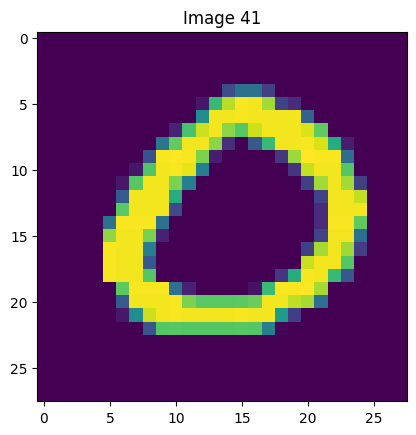

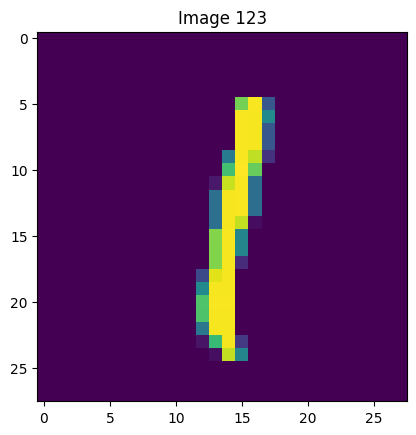

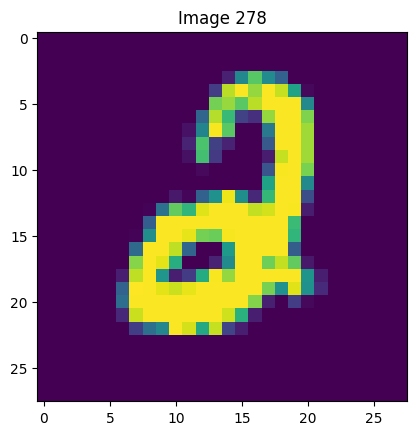

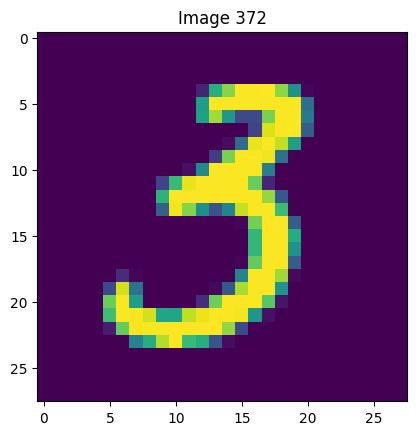

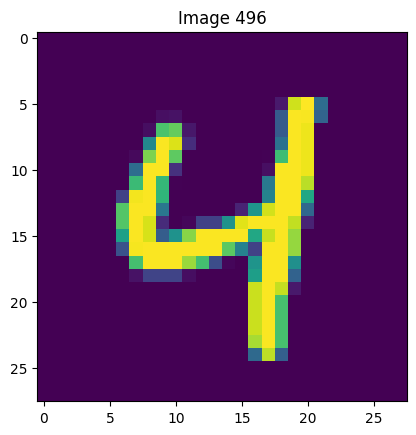

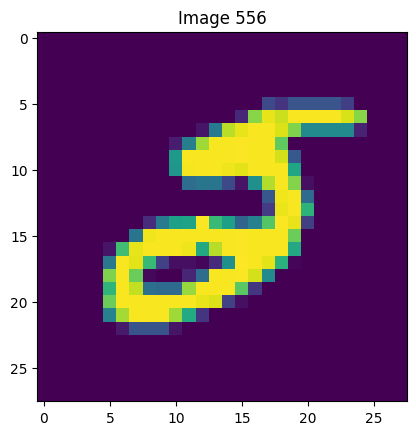

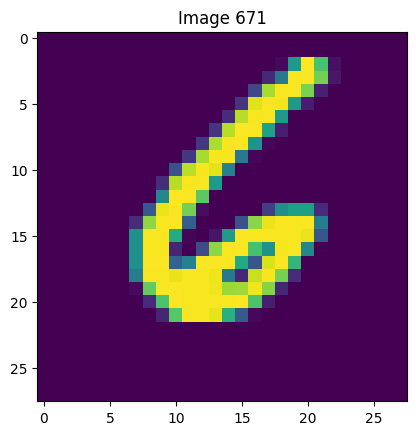

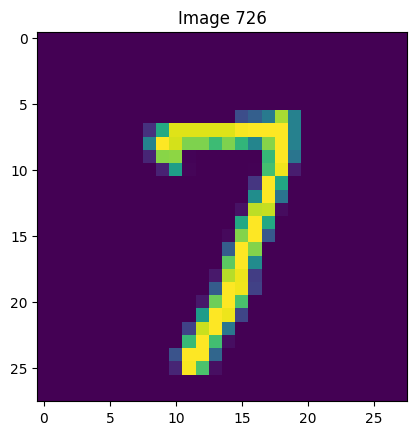

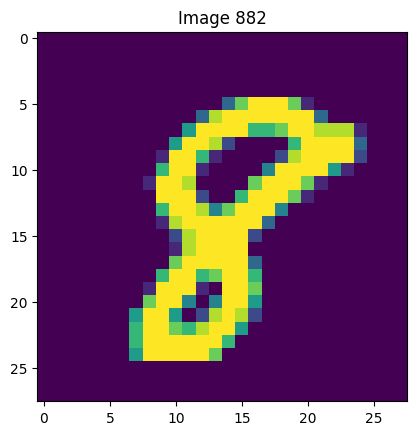

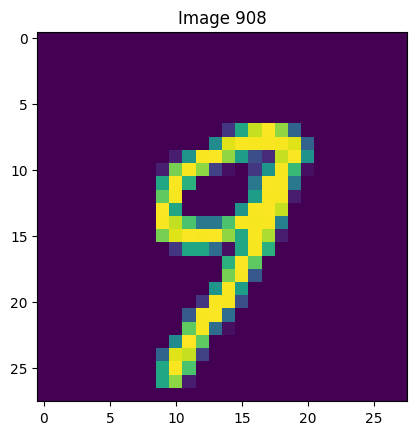

In [5]:
# plot data here (this should have an output)
for i in np.arange(0,10,1):
    index = np.random.randint(0,100) + (i)*100
    image = data[index]
    plt.imshow(image.reshape(28,28))
    plt.title(f"Image {index}")
    plt.show()

# Label data

Select the first 500 examples of 0’s and 1’s for this example, those will form the training data $(x_i , y_i) \in \mathbb{R}^{784} \times \{−1,1\}, i = 1,...,1000$. Assign label $y_i = 1$ for 1s and $y_i = −1$ for 0s.  Also, renormalize your $x_i$ so that the pixel values are floats between 0 and 1, instead of ints from 0 to 255.  You can do this by augmenting the code given above for stacking data from different classes.

In [6]:
# create dataset here (essentially just create a numpy array of 1's and -1's for the labels)
x_train = []
y_train = []
for i in np.arange(0,500):
    x_train.append(digits[0][i].reshape(784) / 255.0)
    y_train.append(-1)

for i in np.arange(0,500):
    x_train.append(digits[1][i].reshape(784) / 255.0)
    y_train.append(1)

# Running Gradient Descent

Implement and run a Gradient Descent algorithm, with step-size $\mu = 10^{-4}$, to optimize the function above associated with this setup. You should run your algorithm for at least $T = 10,000$ iterations, but if your computer can handle it try $T=100,000$ or until a reasonable stopping criterion is satisfied.  Provide a plot showing the value of $F(w)$ at each iteration. Also, feel free to adjust $\mu$ to be larger / smaller if the plot does not match your expectations.

  0%|          | 0/10000 [00:00<?, ?it/s]

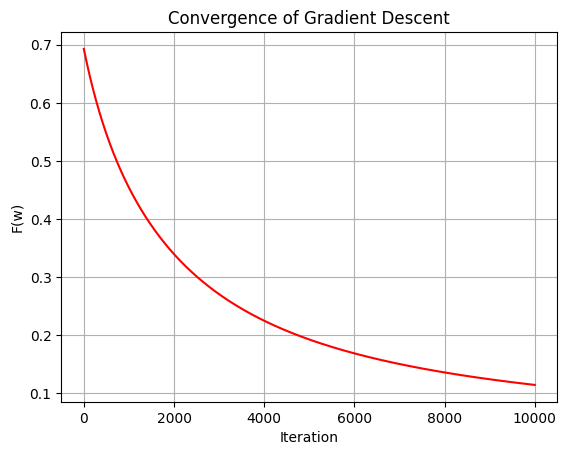

In [7]:
# implement gradient descent here
def F(w, X, y):
    N = len(X)
    output = 0
    for i in np.arange(N):
        output = output + np.log(1 + np.exp(-np.dot(w,X[i])*y[i]))
    output = output/N
    return output

def gradient(w, X, y):
    N = len(X)
    grad = 0
    for i in np.arange(N):
        grad = grad + (-y[i]*X[i]*np.exp(-np.dot(w,X[i])*y[i])/(1 + np.exp(-np.dot(w,X[i])*y[i])))
    grad = grad/N
    return grad

from tqdm.notebook import trange

def descent(w, X, y, mu):
    Fws = []
    for i in trange(10000):
        prev_loss = F(w,X,y)
        w = w - mu * gradient(w, X, y)
        loss = F(w,X,y)
        Fws.append(loss)
        # stopping condition example:
        # if np.abs(loss-prev_loss) < 1e-5:
        #     return Fws, w
    return Fws, w

w = np.zeros(784)
X = x_train
y = y_train
mu = 1e-4

Fws, w_star = descent(w,X,y, mu)

plt.plot(Fws, color = 'red')
plt.title('Convergence of Gradient Descent')
plt.xlabel('Iteration')
plt.ylabel('F(w)')
plt.grid(True)
plt.show()

# (4d) Discussion about gradient descent

Comment on the resulting plot. In particular, does the shape of $F(w)$ suggest you've successfully converged to a local or global minimum?  Does it appear you chose a good stopping criteria?  Explain whether your
answers to these questions are consistent with the theory we discussed in class (and in the
notes). Be specific i.e., point to a specific theorem (or theorems) and indicate
why it does or does not explain the behavior of the algorithm.  Would the theory dictate a different choice of $\mu$ than the one we used?

Put discussion here:

Now, use the $w$ you found from part (a) to classify the first 500 \emph{test} data points associated to
each of the 0 and 1 handwritten digits. Recall that you need to use the function $y = \text{sign}(w^T x)$
to classify. What was the classification error rate associated with the two digits on the test
data (this should be a number between 0 and 1)? What was it on the training data?  Does this relationship make sense?

In [8]:
# Classify and return the classification error
# Form test data
x_test = []
y_test = []
for i in np.arange(500,1000):
    x_test.append(digits[0][i].reshape(784) / 255.0)
    y_test.append(-1)

for i in np.arange(500,1000):
    x_test.append(digits[1][i].reshape(784) / 255.0)
    y_test.append(1)

# Classify and return the classification error
def sign(input):
    if input > 0:
        return 1
    else:
        return -1

def classification_error(w, X_test, y_test):
    predictions = []
    for x in X_test:
        predictions.append(sign(np.dot(w, x)))
    number_of_errors = 0
    for i in range(len(predictions)):
        if predictions[i] != y_test[i]:
            number_of_errors = number_of_errors + 1
    error_rate = number_of_errors / len(y_test)
    return error_rate

w = w_star
X_test = x_test
Y_test = y_test

# Classification error for test data
print("Test error:", classification_error(w, X_test, Y_test))

# Classification error for train data
print("Train error:", classification_error(w, x_train, y_train))

Test error: 0.004
Train error: 0.003


  0%|          | 0/10000 [00:00<?, ?it/s]

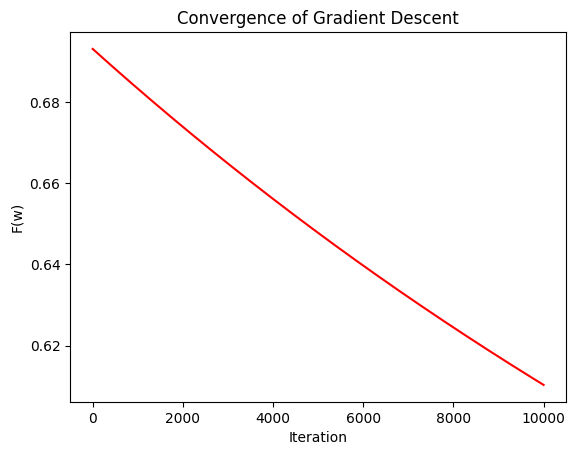

In [9]:
def F(w, X, y):
    N = len(X)
    output = 0
    for i in np.arange(N):
        output = output + np.log(1 + np.exp(-np.dot(w,X[i])*y[i]))
    output = output/N
    return output

# def gradient(w, X, y):
#     N = len(X)
#     grad = 0
#     for i in np.arange(N):
#         grad = grad + (-y[i]*X[i]*np.exp(-np.dot(w,X[i])*y[i])/(1 + np.exp(-np.dot(w,X[i])*y[i])))
#     grad = grad/N
#     return grad

def p(a):
    return np.sign(a) * np.sum(abs(a))

#from tqdm.notebook import trange

def descent_1(w, X, y, mu):
    Fws = []
    for i in trange(10000):
        grad = gradient(w, X, y)
        w = w - mu * p(grad)
        loss = F(w, X, y)
        Fws.append(loss)
    return Fws, w

w = np.zeros(784)
X = x_train
y = y_train
mu = 1e-8
Fws1, w_star1 = descent_1(w,X,y, mu)

plt.plot(Fws1, color = 'red')
plt.title('Convergence of Gradient Descent')
plt.xlabel('Iteration')
plt.ylabel('F(w)')
plt.show()

  0%|          | 0/10000 [00:00<?, ?it/s]

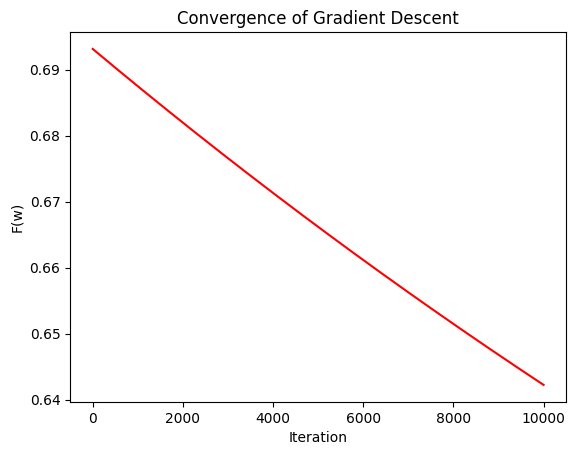

In [10]:
def position(a):
    return np.argmax(np.abs(a))

def p1(a):
    p = np.zeros_like(a)
    j_star = position(a)
    p[j_star] = np.sign(a[j_star]) * np.max(np.abs(a))
    return p

def descent_2(w, X, y, mu):
    Fws = []
    for i in trange(10000):
        grad = gradient(w, X, y)
        w = w - mu * p1(grad)
        loss = F(w, X, y)
        Fws.append(loss)
    return Fws, w

w = np.zeros(784)
X = x_train
y = y_train
mu = 1e-4
Fws2, w_star2 = descent_2(w,X,y, mu)

plt.plot(Fws2, color = 'red')
plt.title('Convergence of Gradient Descent')
plt.xlabel('Iteration')
plt.ylabel('F(w)')
plt.show()

# Conclusion
The gradient descent algorithm in HW 3.5 is better because it is able to converge to the minimum in fewer iterations (faster rate), but the algorithm in question 4 converges slower. It might converge faster with a greater stepsize.


  0%|          | 0/10000 [00:00<?, ?it/s]

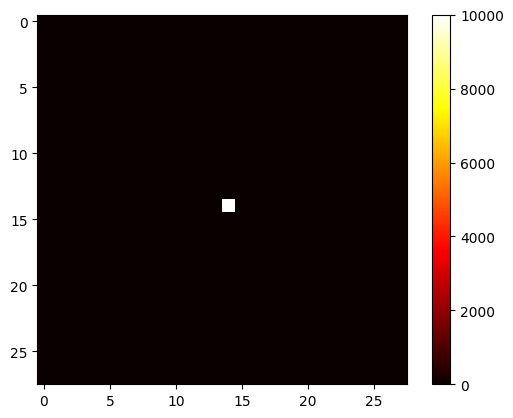

In [11]:
# 6 (4d)
def l1_descent(w, X, y, mu):
    update_counts = np.zeros(784)
    for i in trange(10000):
        grad = gradient(w, X, y)
        update_index = position(p1(grad))
        w = w - mu * p1(grad)
        update_counts[update_index] += 1
    return update_counts, w

X = x_train
y = y_train
w = np.zeros(784)
mu = 1e-4
update_counts, w_star3 = l1_descent(w,X,y,mu)

update_counts_image = update_counts.reshape(28,28)
plt.imshow(update_counts_image, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

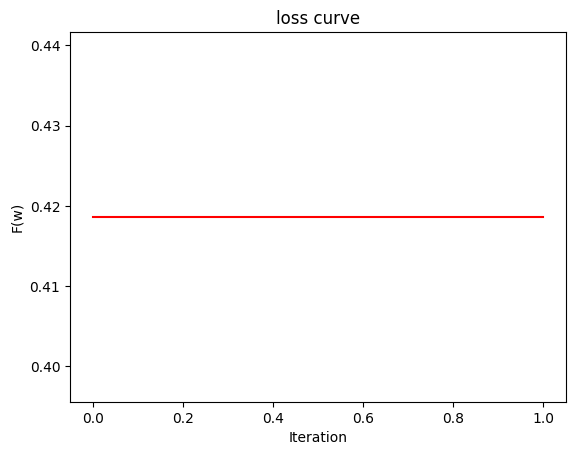

In [13]:
def f(w, X, y):
    N = len(X)
    output = 0
    for i in np.arange(N):
        output = output + np.log(1 + np.exp(-np.dot(w,X[i])*y[i]))
    output = output/N
    return output

def backtracking_line_search(beta, gamma, grad, X, y):
    mu = 1e-1
    for i in range(10000):
        w_new = w - mu * grad
        if f(w_new, X, y) <= f(w, X, y) - mu * gamma * np.linalg.norm(gradient(w, X, y)) ** 2:
            return mu
        else:
            mu = beta * mu
    return mu

def GD_back_search(w, X, y, beta, gamma):
    fws = []
    beta = beta
    gamma = gamma
    for i in trange(1000):
        grad = gradient(w, X, y)
        prev_loss = f(w, X, y)
        mu = backtracking_line_search(beta, gamma, grad, X, y)
        w = w - mu * grad
        loss = f(w,X,y)
        fws = np.append(fws, loss)
        if np.abs(loss - prev_loss) < 1e-10:
            return w, fws
    return w, fws

w = np.zeros(784)
X = x_train
y = y_train
beta = 0.8
gamma = 0.5
w_star1, fws = GD_back_search(w, X, y, beta, gamma)

plt.plot(fws, color = 'red')
plt.title('loss curve')
plt.xlabel('Iteration')
plt.ylabel('F(w)')
plt.show()

In [14]:
# [36]: gradient descent with momentum
def momentum_descent(w, X, y, beta, mu):
    fws_2 = []
    w_prev = w
    for i in trange(10000):
        grad = gradient(w, X, y)
        prev_loss_2 = f(w, X, y)
        momentum = (w - w_prev) * beta
        w_new = w - mu * grad + momentum
        w_prev = w
        w = w_new
        loss_2 = f(w,X,y)
        fws_2 = np.append(fws_2, loss_2)
        if np.abs(loss_2 - prev_loss_2) < 1e-6:
            return w, fws
    return w, fws_2

w = np.zeros(784)
beta = 0.8
mu = 1e-4
w_star2, fws_2 = momentum_descent(w,X,y, beta, mu)

  0%|          | 0/10000 [00:00<?, ?it/s]

In [15]:
def Nesterov_acc(w, X, y, beta, mu):
    fws_3 = []
    w_prev = w
    for i in trange(10000):
        w_diff = w - w_prev
        momentum = beta * w_diff
        grad = gradient(w + momentum , X, y)
        prev_loss_3 = f(w, X, y)
        w_new = w - mu * grad + momentum
        w_prev = w
        w = w_new
        loss_3 = f(w,X,y)
        fws_3 = np.append(fws_3, loss_3)
        if np.abs(loss_3 - prev_loss_3) < 1e-6:
            return w, fws_3
    return w, fws_3

w = np.zeros(784)
beta = 0.8
mu = 1e-4
w_star3, fws_3 = Nesterov_acc(w,X,y, beta, mu)

  0%|          | 0/10000 [00:00<?, ?it/s]

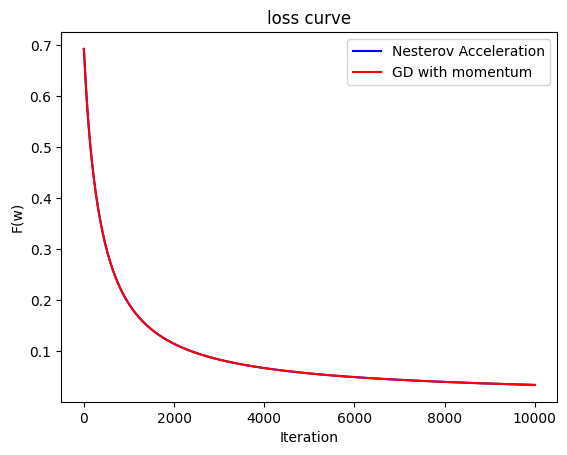

In [18]:
# [41]: compare curves
plt.plot(fws_3, color = 'blue', label = 'Nesterov Acceleration')
plt.plot(fws_2, color = 'red', label = 'GD with momentum')
plt.title('loss curve')
plt.xlabel('Iteration')
plt.ylabel('F(w)')
plt.legend()
plt.show()

# [42]: Note: Nesterov and momentum converge faster than backtracking line search
